# Latitudinal Structure

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.floating_axes as FA
import mpl_toolkits.axisartist.grid_finder as GF
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [3]:
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [4]:
AV = xr.open_dataset('AV.nc').AV.compute()

In [5]:
Pumping = xr.open_dataset('AV.nc').Epumping.compute()
Pumping

<xarray.DataArray 'Epumping' (time: 432, lat: 159, lon: 194)> Size: 107MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
    year     (time) int64 3kB 1980 1980 1980 1980 1980 ... 2015 2015 2015 2015
    month    (time) int64 3kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12

In [6]:
Ek_t = xr.open_dataset('Winds_components_Lu.nc').U_ek_cross.isel(offshore=0)
Ek_t = (Ek_t.swap_dims({'coast_point': 'lat'})
         .drop_vars(['coast_point', 'lon', 'bearing', 'distance', 'f', 'offshore'])
         .rename('Ek_t'))
Ek_t

<xarray.DataArray 'Ek_t' (time: 432, lat: 159)> Size: 550kB
[68688 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Attributes:
    units:      m^2/s
    long_name:  Cross-shore Ekman transport (BUI)

In [7]:
CUTI = xr.open_dataset('CUTI_BEUTI_components.nc').CUTI.compute()
BEUTI = xr.open_dataset('CUTI_BEUTI_components.nc').BEUTI.compute()
ugeo = xr.open_dataset('CUTI_BEUTI_components.nc').u_geo.compute()
UGEO = xr.open_dataset('CUTI_BEUTI_components.nc').UGEO.compute()
CROCO_j = xr.open_dataset('CUTI_BEUTI_components.nc').CROCO_j.compute()
d = xr.open_dataset('CUTI_BEUTI_components.nc').cross_shore_distance.compute()

In [8]:
CUI = xr.open_dataset('CUI.nc').compute()
CUI

<xarray.Dataset> Size: 279kB
Dimensions:  (time: 432, lat: 159)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    CUI_cc   (time, lat) float32 275kB 0.6532 0.8731 1.075 ... 0.9314 0.8585

In [9]:
## CROCO
wmld = xr.open_dataset('../W_mld_Croco.nc').compute()
mask = coastal_band_mask(wmld,'WMLD', 250)
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-2))
wmld

<xarray.Dataset> Size: 148MB
Dimensions:  (time: 432, lat: 221, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -2.249 -2.166 -2.082
Data variables:
    WMLD     (time, lat, lon) float64 148MB nan nan nan nan ... nan nan nan nan

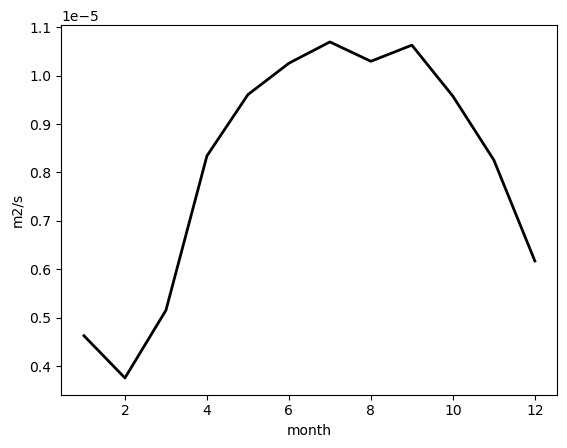

In [10]:
seasonality(wmld).sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).WMLD.rename('m2/s').plot(label='Croco',linewidth=2,color='black')


In [11]:
#Chlorphyll
CHL = xr.open_dataset('../../../../NHCS/hincast_1980-2015/Chlorophyll_CROCO.nc').drop_vars('s_rho').compute()
CHL = CHL.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-2))
CHL

<xarray.Dataset> Size: 148MB
Dimensions:  (time: 432, lat: 221, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -2.249 -2.166 -2.082
Data variables:
    chla     (time, lat, lon) float64 148MB nan nan nan nan ... nan nan nan nan

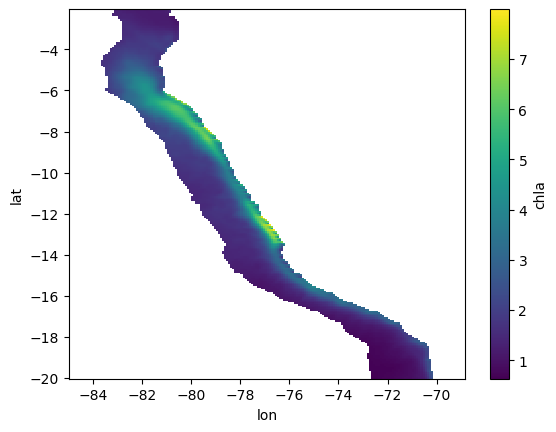

In [12]:
CHL.chla.std('time').plot()

## Latitudinal Structure

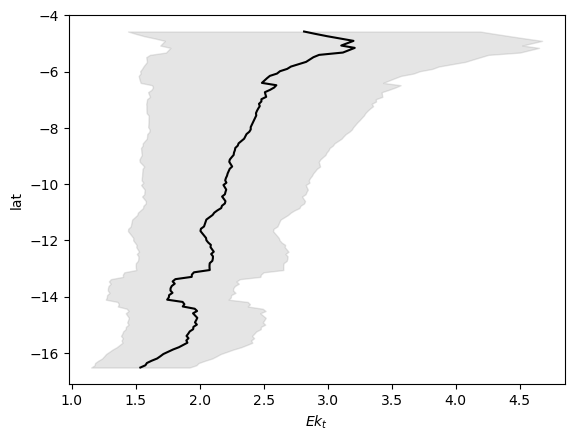

In [13]:
std = Ek_t.std(dim='time').rolling(lat=13, center=True).mean().rename('$Ek_t$')
mean = Ek_t.mean('time').rolling(lat=13,center=True).mean().rename('$Ek_t$')

Ek_t.mean('time').rolling(lat=13,center=True).mean().rename('$Ek_t$').plot(y='lat',color='black', linewidth=1.5)
plt.fill_betweenx(mean.lat,
                        mean - std,
                        mean + std,
                        color='gray',
                        alpha=0.2,
                        label='±1 SD')
    

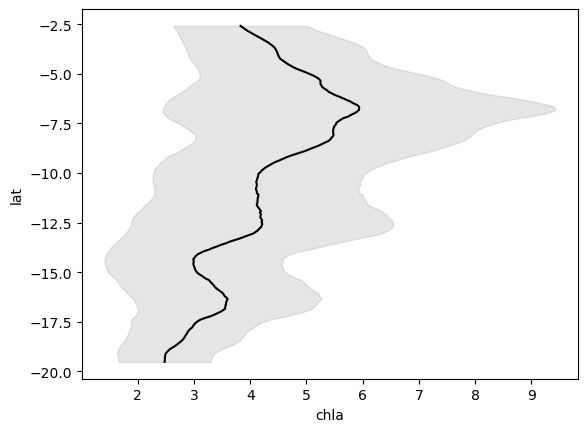

In [14]:
std = CHL.mean('lon').chla.std(dim='time').rolling(lat=13, center=True).mean()
mean = CHL.mean('lon').chla.mean('time').rolling(lat=13,center=True).mean()

CHL.mean(dim=('lon','time')).chla.rolling(lat=13,center=True).mean().plot(y='lat',color='black', linewidth=1.5)
plt.fill_betweenx(mean.lat,
                        mean - std,
                        mean + std,
                        color='gray',
                        alpha=0.2,
                        label='±1 SD')

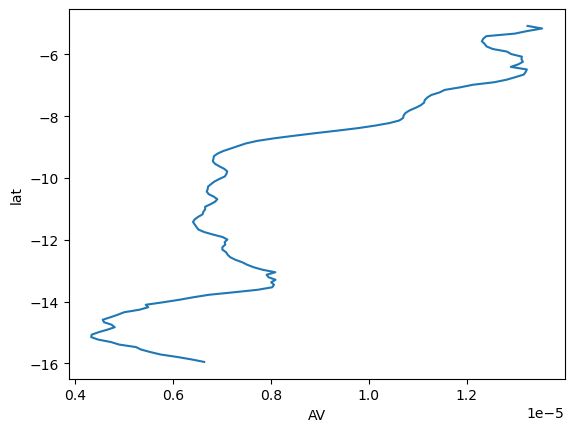

In [15]:
AV.mean(dim=('time','lon')).rolling(lat=13,center=True).mean().sel(lat=slice(-16,-5)).plot(y='lat')

In [16]:
BEUTI.mean(dim=('time'))

<xarray.DataArray 'BEUTI' (lat_band: 13)> Size: 104B
array([22.47614667, 30.48596814, 31.36211978, 36.85365161, 30.27365261,
       40.00799344, 35.64328579, 30.26599608, 28.38944211, 45.40717379,
       25.60123654, 21.9304699 , 14.20570794])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

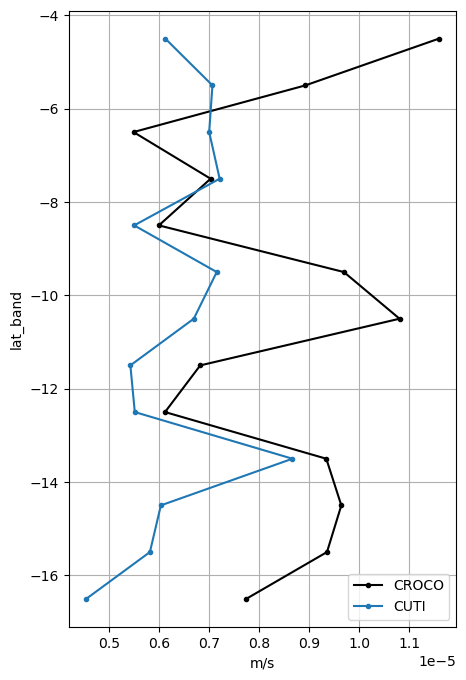

In [17]:
CROCO_j.mean(dim=('time')).plot(y='lat_band',label='CROCO', color='Black',marker='.',figsize=(5,8))
(CUTI/d).mean(dim=('time')).rename('m/s').plot(y='lat_band',label='CUTI',marker='.')
plt.grid()
plt.legend()
# plt.savefig('latitudinal/CUTI_Croco.jpg')

### Plot for the Paper

In [18]:
R = 6371000.0

# convert degree spacing to radians
dlon = np.deg2rad(1/12)

# latitude in radians (2D or 1D broadcastable)
lat_rad = np.deg2rad(wmld['lat'])

# dx (meters), varies with latitude
dx = R * np.cos(lat_rad) * dlon

(-6.0, 6.0)

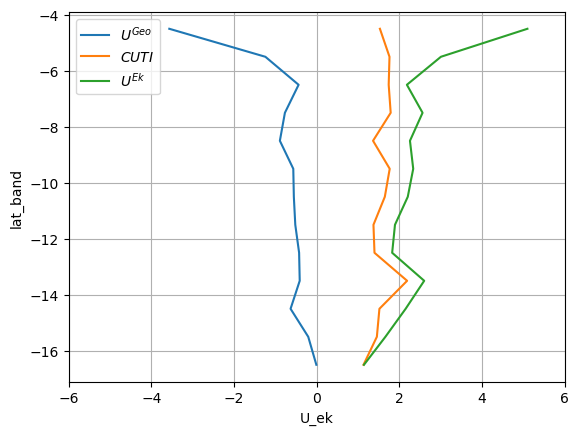

In [19]:
UGEO.mean(dim=('time')).plot(y='lat_band',label='$U^{Geo}$')
CUTI.mean(dim=('time')).plot(y='lat_band',label='$CUTI$')
xr.open_dataset('CUTI_BEUTI_components.nc').U_ek.compute().mean(dim=('time')).plot(y='lat_band',label='$U^{Ek}$')
plt.legend()
plt.grid(True)
plt.xlim([-6,6])

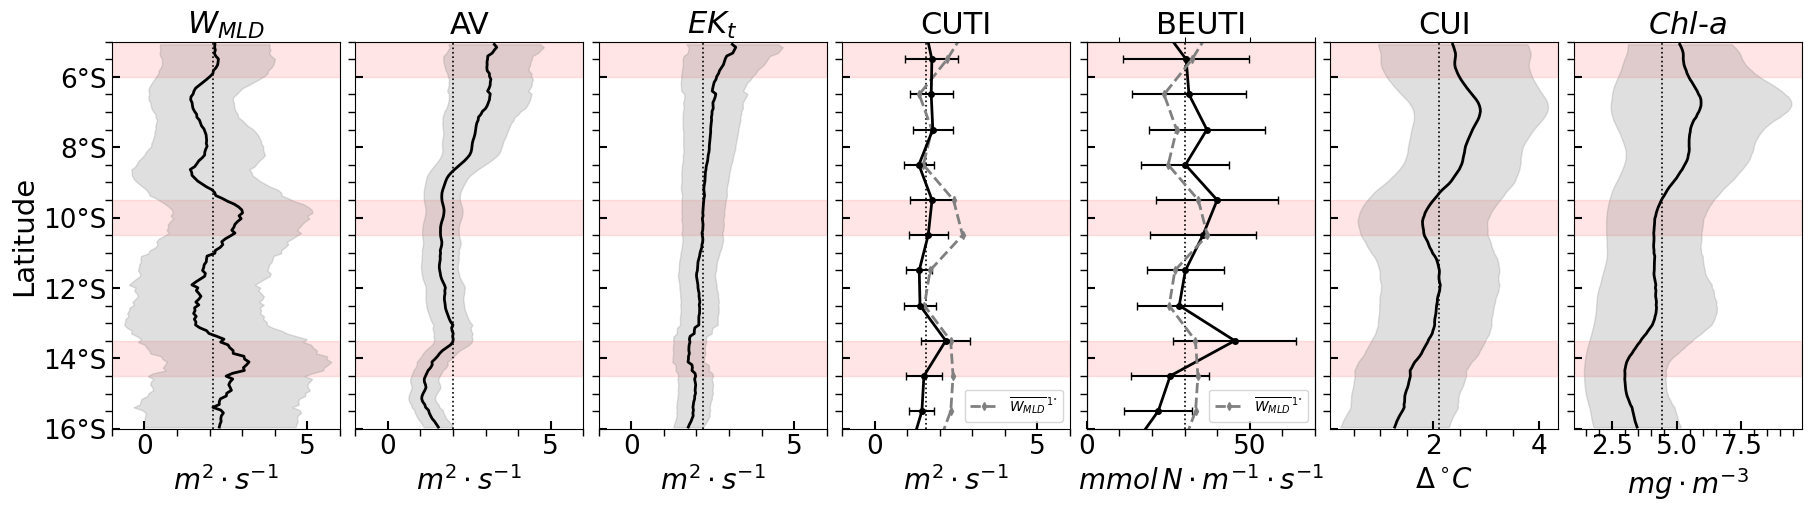

In [23]:
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator, FuncFormatter
from matplotlib.backends.backend_pdf import PdfPages

lsz= 6
# Publication font sizes
mpl.rcParams.update({
    'font.size':       14,
    'axes.titlesize':  16,
    'axes.labelsize':  15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'pdf.fonttype':    42,
})

# d = (1/12) * 10 * 111 * 1000

data_dict = {
    "WMLD":  (wmld.WMLD * dx).sum(dim='lon'),
    "AV":    (AV * dx).sum(dim='lon'),
    "EkT":   Ek_t,
    "CUI":   CUI.CUI_cc,
    "CUTI":  CUTI.rename({'lat_band': 'lat'}),
    "BEUTI": BEUTI.rename({'lat_band': 'lat'}),
    "Chla": CHL.mean('lon').chla,
}

indx  = ['WMLD', 'AV', 'EkT', 'CUTI', 'BEUTI', 'CUI','Chla']
units = [
    r'$m^{2} \cdot s^{-1}$',
    r'$m^{2} \cdot s^{-1}$',
    r'$m^{2} \cdot s^{-1}$',
    r'$m^{2} \cdot s^{-1}$',
    r'$mmol\,N \cdot m^{-1} \cdot s^{-1}$',
    r'$\Delta\,^{\circ}C$',
    r'$mg \cdot m^{-3}$'
]

# Pretty title labels (with subscripts and proper formatting)
title_labels = {
    'WMLD':  r'$W_{MLD}$',
    'AV':    'AV',
    'EkT':   r'$EK_t$',
    'CUTI':  'CUTI',
    'BEUTI': 'BEUTI',
    'CUI':   'CUI',
    'Chla':   r'$Chl\text{-}a$',
}

xlims = {
    'WMLD': (-1, 6),
    'AV':   (-1, 6),
    'EkT':  (-1, 6),
    'CUTI': (-1, 6),
    'BEUTI': (0,70),
    
}

def lat_formatter(y, _):
    if y == 0:
        return '0°'
    return f'{abs(int(y))}°{"S" if y < 0 else "N"}'

fig, axes = plt.subplots(1, 7, figsize=(18, 5), constrained_layout=True)
axes = np.array(axes).flatten()

for i, key in enumerate(indx):
    ax = axes[i]
    da = data_dict[key]

    if da.lat.size > 15:
        mean = da.mean("time").rolling(lat=13, center=True).mean().sel(lat=slice(-16, -5))
        std  = da.std("time").rolling(lat=13, center=True).mean().sel(lat=slice(-16, -5))
        lat  = da.lat.sel(lat=slice(-16, -5))
    else:
        mean = da.mean("time")
        std  = da.std("time")
        lat  = da.lat
        
    if da.lat.size > 15:
        ax.plot(mean, lat, color="black", lw=2)
        ax.fill_betweenx(lat, mean - std, mean + std, alpha=0.25, color='gray')
    else:
        ax.errorbar(mean, lat, xerr=std, color='black', lw=2, marker='o', ms=4,
                    capsize=3, ecolor='black', elinewidth=1.5)

    ax.axvline(mean.mean(), color='black', linestyle=':', lw=1.2, alpha=1)
# Add CROCO_j reference on the CUTI panel
    if key == 'CUTI':
        croco_mean = (CROCO_j * 250 * 1000).mean(dim=('time'))
        
        ax.plot(croco_mean, CROCO_j.lat_band, 
        color='gray', lw=2, linestyle='--',
        marker='d', ms=4,
        label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
        
        ax.legend(fontsize=10, loc='lower right')

    if key == 'BEUTI':
        croco_mean = (CROCO_j * 250 * 1000).mean(dim=('time'))
        ax2 = ax.twiny()
        ax2.plot(croco_mean, croco_mean.lat_band, color='gray', lw=2, linestyle='--',  marker='d',ms=4,label=r'$\overline{W_{MLD}}^{\,1^{\circ}}$')
        ax2.set_xticklabels([])
        ax2.set_xlim(-1, 6)
        # ax2.set_xticks([])
        ax2.set_xlabel('')
        ax2.legend(fontsize=10, loc='lower right')
        
    ax.set_title(title_labels[key], fontsize=16+lsz, fontweight='normal')
    ax.set_xlabel(units[i], fontsize=14+lsz)
    ax.set_ylim([-16, -5])

    # Highlight upwelling centers
    upwelling_centers = [(-6, -5), (-10.5, -9.5), (-14.5, -13.5)]
    for ybot, ytop in upwelling_centers:
        ax.axhspan(ybot, ytop, color='red', alpha=0.1, zorder=0)
        
    # ax.grid(which='major', alpha=0.5)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    # ax.grid(which='minor', alpha=0.2)
    ax.tick_params(axis='both', labelsize=13+lsz, direction='in', size=6, width=1.5)
    ax.tick_params(which='minor', size=3+2, width=1)

    # Format latitude as "5°S", "10°S", etc.
    ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

    if i == 0:
        ax.set_ylabel('Latitude', fontsize=15+lsz)
    else:
        ax.set_yticklabels([])

    if key in xlims:
        ax.set_xlim(xlims[key])

# fig.suptitle('Latitudinal mean and variability of upwelling indices (1980–2015)',
#              fontsize=17, fontweight='bold')

# # --- Save ---
# with PdfPages('Figures/Indices_latitudinal.pdf') as pdf:
#     pdf.savefig(fig, bbox_inches='tight', dpi=300)

plt.show()

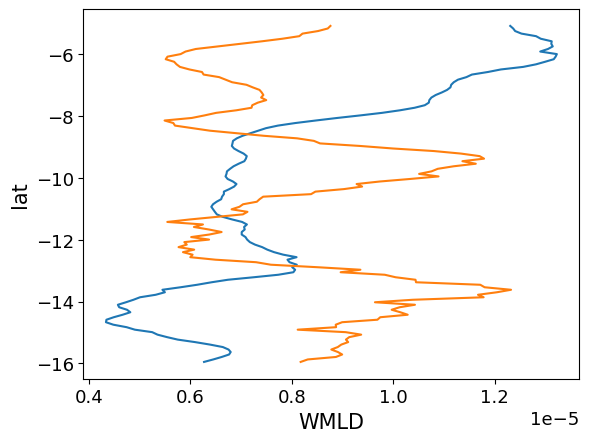

In [21]:
AV.mean(dim=('time','lon')).rolling(lat=13).mean().sel(lat=slice(-16,-5)).plot(y='lat')
wmld.WMLD.mean(dim=('time','lon')).rolling(lat=13).mean().sel(lat=slice(-16,-5)).plot(y='lat')

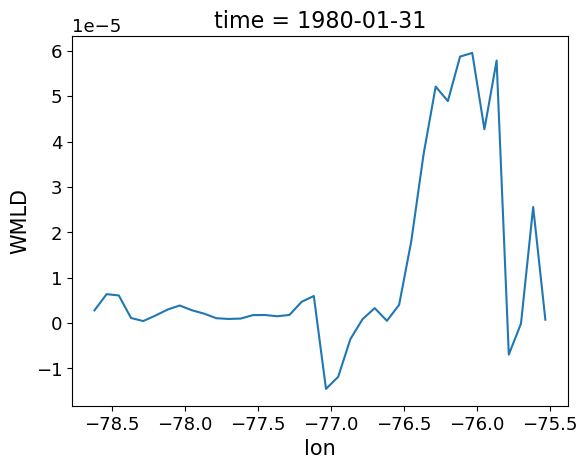

In [22]:
wmld.WMLD.isel(time=0).sel(lat=slice(-15,-14)).mean('lat',skipna=True).plot()